In [21]:
# EDA AND MACHINE LEARNING ON AGRICULTURAL YIELD DATASET

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Load Dataset
df = pd.read_csv("agriculture_yield_dataset.csv")

In [22]:
# Q1. DATASET OVERVIEW
print("Rows and Columns:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 10 Records:")
print(df.head(10))

Rows and Columns: (1500, 8)

Column Names:
['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare']

First 10 Records:
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   
5        831.9           28.0          190.3               2.1      6.1   
6       1023.8           32.0          108.5               6.9      6.2   
7       1142.4           18.4          241.9               4.1      7.3   
8        810.4           36.4          164.8               9.9      6.5   
9       1085.5           29.4           89.3            

In [23]:
# Q2. DATA TYPES AND MISSING VALUES
print("\nQ2. Data Types and Missing Values")

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())



Q2. Data Types and Missing Values

Data Types:
rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object

Missing Values:
rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64


In [24]:
# Q3. DESCRIPTIVE STATISTICS
print("\nQ3. Descriptive Statistics")

stats = df.describe()
print(stats)

means = df.select_dtypes(include=np.number).mean()
stds = df.select_dtypes(include=np.number).std()

print("\nFeature with Highest Mean:")
print(means.idxmax(), "=", means.max())

print("\nFeature with Highest Standard Deviation:")
print(stds.idxmax(), "=", stds.max())


Q3. Descriptive Statistics
       rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  \
count  1500.000000    1500.000000    1500.000000       1500.000000   
mean    754.054667      27.749467     148.744067          5.403267   
std     255.097216       5.758101      56.990279          2.584329   
min     300.200000      18.000000      50.300000          1.000000   
25%     536.175000      22.600000      98.600000          3.200000   
50%     761.200000      27.700000     146.850000          5.400000   
75%     964.375000      32.600000     196.575000          7.600000   
max    1200.000000      38.000000     249.900000         10.000000   

           soil_ph  yield_ton_per_hectare  
count  1500.000000            1500.000000  
mean      6.759133               5.028793  
std       0.719742               0.968282  
min       5.500000               2.090000  
25%       6.100000               4.337500  
50%       6.800000               5.010000  
75%       7.400000               

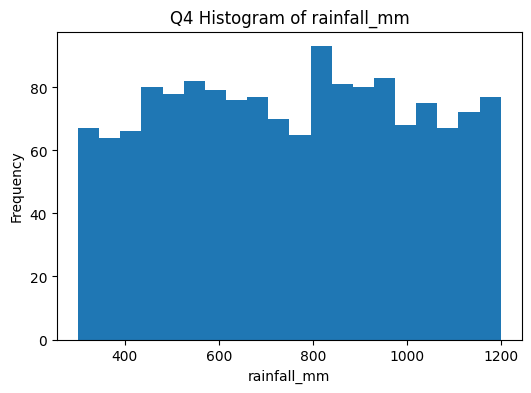

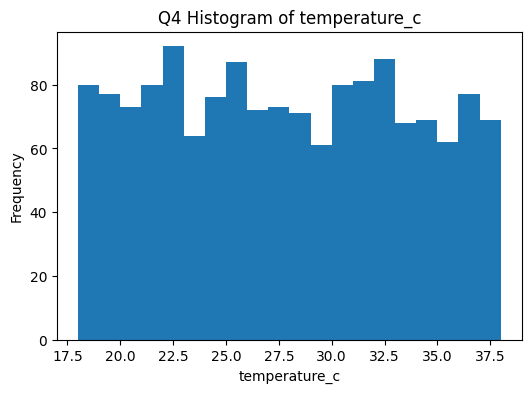

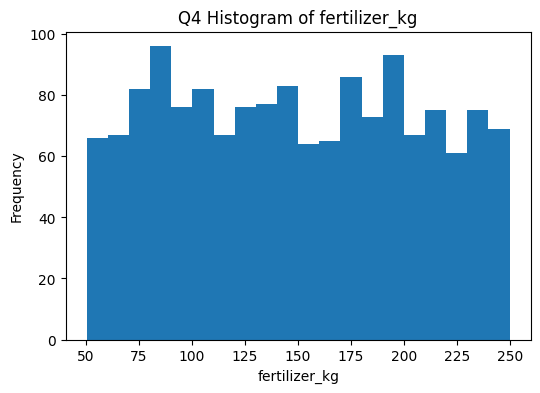

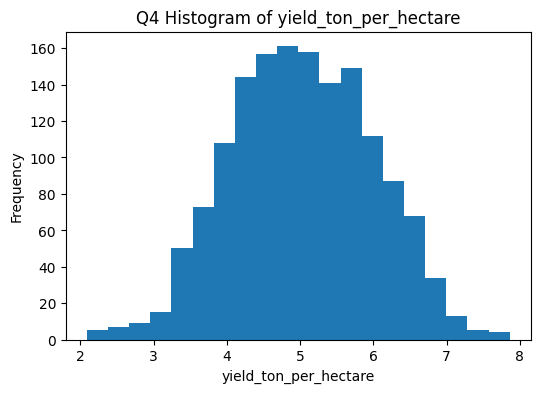

In [25]:
# Q4. DISTRIBUTION ANALYSIS
columns = [
    'rainfall_mm',
    'temperature_c',
    'fertilizer_kg',
    'yield_ton_per_hectare'
]

for col in columns:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=20)
    plt.title(f"Q4 Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


Q5. Crop Type Analysis
crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


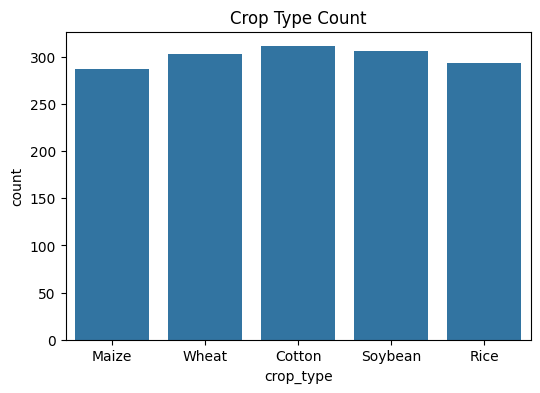


Most Frequent Crop:
Cotton


In [26]:
# Q5. CROP TYPE ANALYSIS
print("\nQ5. Crop Type Analysis")

crop_counts = df['crop_type'].value_counts()
print(crop_counts)

plt.figure(figsize=(6,4))
sns.countplot(x='crop_type', data=df)
plt.title("Crop Type Count")
plt.show()

print("\nMost Frequent Crop:")
print(df['crop_type'].mode()[0])


Q6. Soil Type Analysis
soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


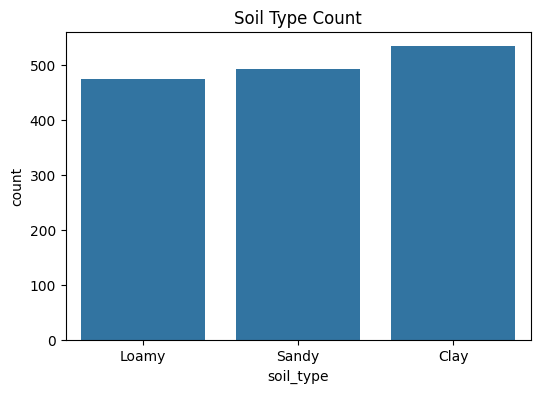


Most Common Soil:
Clay


In [27]:
# Q6. SOIL TYPE ANALYSIS
print("\nQ6. Soil Type Analysis")

soil_counts = df['soil_type'].value_counts()
print(soil_counts)

plt.figure(figsize=(6,4))
sns.countplot(x='soil_type', data=df)
plt.title("Soil Type Count")
plt.show()

print("\nMost Common Soil:")
print(df['soil_type'].mode()[0])

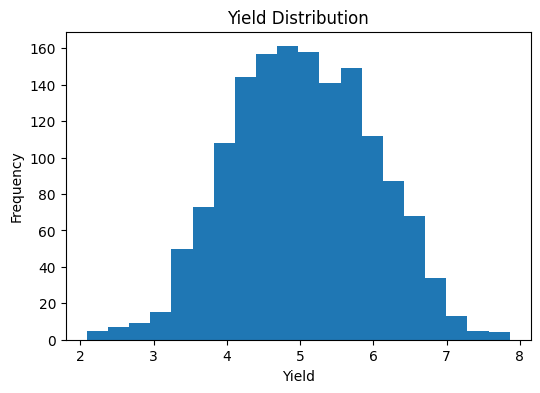

In [28]:
# Q7. YIELD DISTRIBUTION
plt.figure(figsize=(6,4))
plt.hist(df['yield_ton_per_hectare'], bins=20)
plt.title("Yield Distribution")
plt.xlabel("Yield")
plt.ylabel("Frequency")
plt.show()

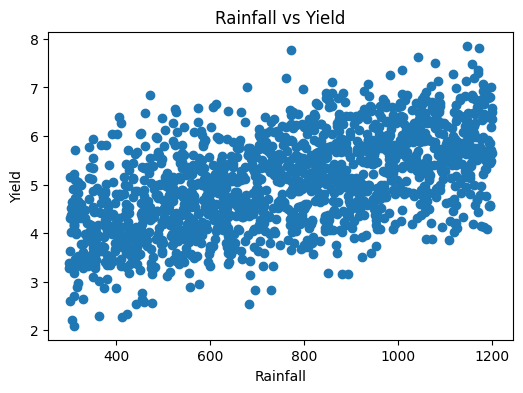

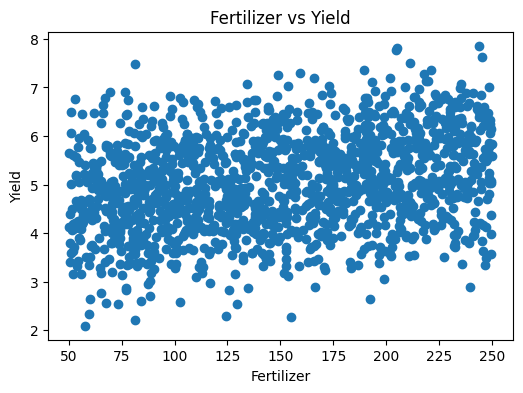

In [29]:
# Q8. SCATTER PLOT ANALYSIS
plt.figure(figsize=(6,4))
plt.scatter(df['rainfall_mm'], df['yield_ton_per_hectare'])
plt.xlabel("Rainfall")
plt.ylabel("Yield")
plt.title("Rainfall vs Yield")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(df['fertilizer_kg'], df['yield_ton_per_hectare'])
plt.xlabel("Fertilizer")
plt.ylabel("Yield")
plt.title("Fertilizer vs Yield")
plt.show()


Q9. Correlation Analysis
                       rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000       0.026721       0.002558   
temperature_c             0.026721       1.000000       0.037468   
fertilizer_kg             0.002558       0.037468       1.000000   
irrigation_hours          0.010877       0.007114      -0.010497   
soil_ph                   0.006916       0.001513       0.010001   
yield_ton_per_hectare     0.553704      -0.022559       0.278043   

                       irrigation_hours   soil_ph  yield_ton_per_hectare  
rainfall_mm                    0.010877  0.006916               0.553704  
temperature_c                  0.007114  0.001513              -0.022559  
fertilizer_kg                 -0.010497  0.010001               0.278043  
irrigation_hours               1.000000  0.009307               0.542664  
soil_ph                        0.009307  1.000000               0.024412  
yield_ton_per_hectare          0.542664  0.0244

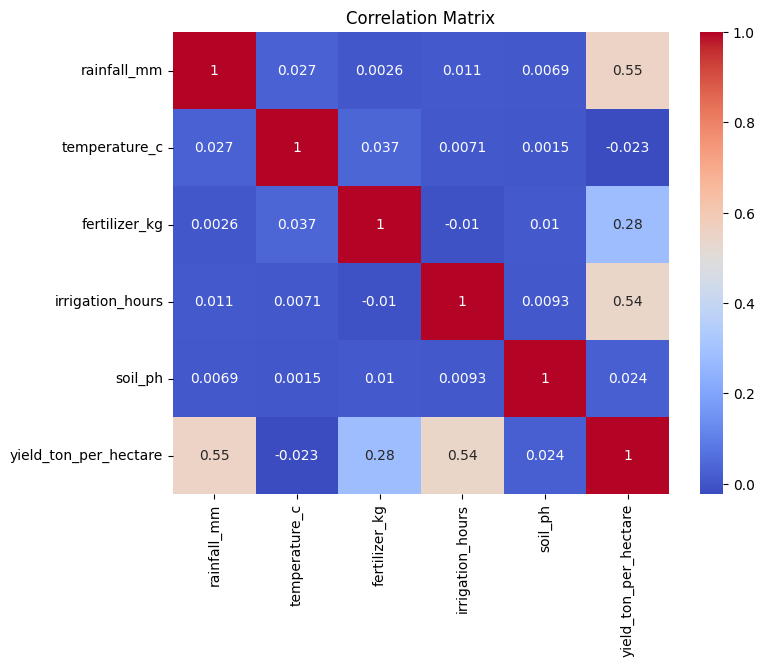


Top Features Correlated with Yield:
yield_ton_per_hectare    1.000000
rainfall_mm              0.553704
irrigation_hours         0.542664
fertilizer_kg            0.278043
soil_ph                  0.024412
temperature_c           -0.022559
Name: yield_ton_per_hectare, dtype: float64


In [30]:
# Q9. CORRELATION ANALYSIS
print("\nQ9. Correlation Analysis")

corr = df.select_dtypes(include=np.number).corr()

print(corr)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

yield_corr = corr['yield_ton_per_hectare'].sort_values(ascending=False)

print("\nTop Features Correlated with Yield:")
print(yield_corr)


In [31]:
# Q10. GROUP BASED ANALYSIS
print("\nQ10. Group Based Analysis")

crop_avg = df.groupby('crop_type')['yield_ton_per_hectare'].mean()
print("\nAverage Yield by Crop Type:")
print(crop_avg)

soil_avg = df.groupby('soil_type')['yield_ton_per_hectare'].mean()
print("\nAverage Yield by Soil Type:")
print(soil_avg)

print("\nCrop with Highest Average Yield:")
print(crop_avg.idxmax())

print("\nSoil with Highest Average Yield:")
print(soil_avg.idxmax())


Q10. Group Based Analysis

Average Yield by Crop Type:
crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64

Average Yield by Soil Type:
soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64

Crop with Highest Average Yield:
Rice

Soil with Highest Average Yield:
Loamy


In [32]:
# Q11. FEATURE ENCODING
print("\nQ11. Feature Encoding")

categorical_cols = ['crop_type', 'soil_type']

encoded_df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

print(encoded_df.head())


Q11. Feature Encoding
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   

   yield_ton_per_hectare  crop_type_Maize  crop_type_Rice  crop_type_Soybean  \
0                   5.92             True           False              False   
1                   6.24             True           False              False   
2                   4.77            False           False              False   
3                   4.04             True           False              False   
4                   5.17            False           False              False   

   crop_type_Wheat  soil_type_Loamy  soil_typ

In [33]:
# Q12. FEATURE SELECTION
print("\nQ12. Feature Selection")

X = encoded_df.drop('yield_ton_per_hectare', axis=1)
y = encoded_df['yield_ton_per_hectare']

print("Target Variable:")
print("yield_ton_per_hectare")


Q12. Feature Selection
Target Variable:
yield_ton_per_hectare


In [34]:
# Q13. TRAIN TEST SPLIT
print("\nQ13. Train Test Split")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=4
)



Q13. Train Test Split


In [36]:
# Q14. LINEAR REGRESSION MODEL
print("\nQ14. Linear Regression Model")

model = LinearRegression()

model.fit(X_train, y_train)

print("\nIntercept:")
print(model.intercept_)

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print("\nCoefficients:")
print(coef_df)

highest_positive = coef_df.loc[
    coef_df['Coefficient'].idxmax()
]

print("\nFeature with Highest Positive Coefficient:")
print(highest_positive)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)



Q14. Linear Regression Model

Intercept:
1.5486837606445967

Coefficients:
              Feature  Coefficient
0         rainfall_mm     0.002036
1       temperature_c    -0.008247
2       fertilizer_kg     0.005120
3    irrigation_hours     0.195355
4             soil_ph     0.003118
5     crop_type_Maize     0.272521
6      crop_type_Rice     0.897949
7   crop_type_Soybean     0.480499
8     crop_type_Wheat     0.356607
9     soil_type_Loamy     0.302595
10    soil_type_Sandy    -0.491286

Feature with Highest Positive Coefficient:
Feature        crop_type_Rice
Coefficient          0.897949
Name: 6, dtype: object
X_train: (1200, 11)
X_test: (300, 11)
y_train: (1200,)
y_test: (300,)
